In [166]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [167]:
df = pd.read_csv("train.csv")
# print(df.head())
# print(df.info())
# print(df.describe())
print(df.shape)
print(df.columns)

(1460, 81)
Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 

In [168]:
# print(df.isnull())
print(df.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


In [169]:
# df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].mean())
# print(df.dropna(subset=['LotFrontage']).shape[0])

# Option 3: Count before and after
print(f"Rows before: {len(df)}")
# df.dropna(subset=['LotFrontage'], inplace=True)
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].mean())
print(f"Rows after: {len(df)}")
# df.dropna(subset=['Alley'], inplace=True)
print(df.shape)

Rows before: 1460
Rows after: 1460
(1460, 81)


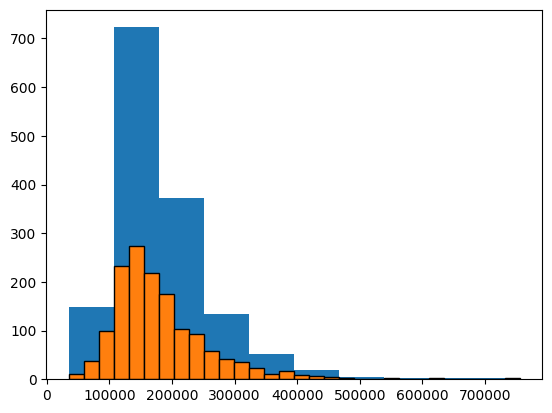

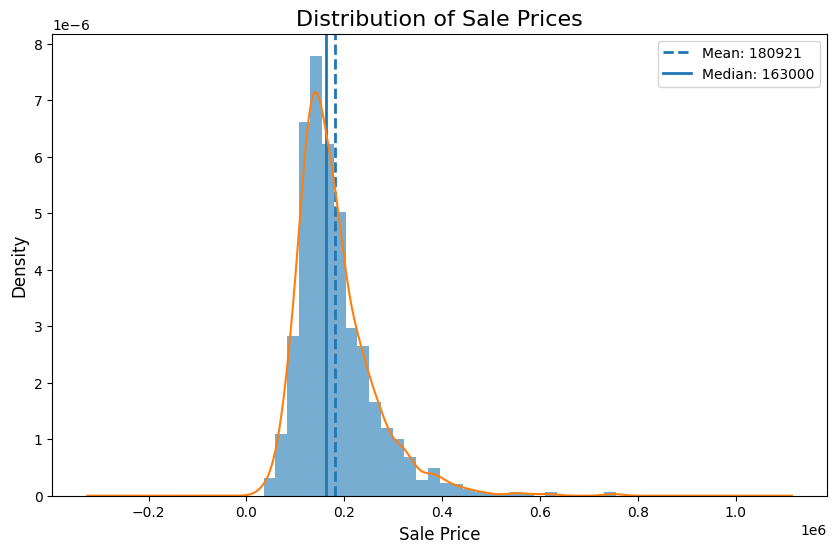

In [170]:
plt.hist(df["SalePrice"])

plt.hist(df["SalePrice"], bins=30, edgecolor='black')

plt.figure(figsize=(10,6))
plt.title("Distribution of Sale Prices", fontsize=16)
plt.xlabel("Sale Price", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Add mean & median lines
mean_val = df["SalePrice"].mean()
median_val = df["SalePrice"].median()

plt.axvline(mean_val, linestyle='dashed', linewidth=2, label=f"Mean: {int(mean_val)}")
plt.axvline(median_val, linestyle='solid', linewidth=2, label=f"Median: {int(median_val)}")

plt.legend()
plt.grid(True)

plt.hist(df["SalePrice"], bins=30, density=True, alpha=0.6)

df["SalePrice"].plot(kind='kde')

plt.show()

In [171]:
df["SalePrice"] = np.log(df["SalePrice"])

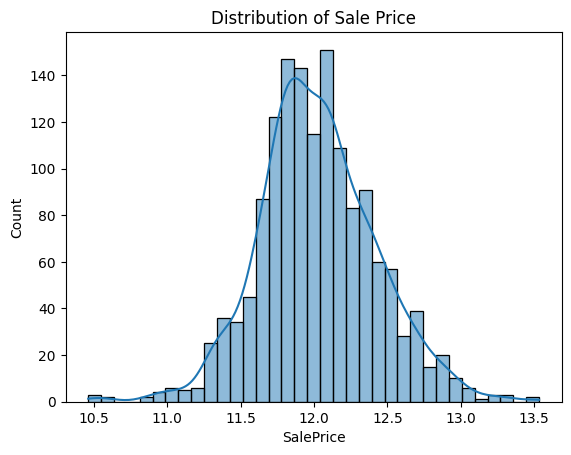

In [172]:

sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribution of Sale Price")
plt.show()

# Right Skewed Distribution (VERY IMPORTANT)
# Most values are on the left (lower prices)
# Tail is stretched to the right (high prices)


# Majority of Houses Range
# Most houses are between ~100k – 200k

# 👉 Insight:

# “Most properties fall in the mid-price range”

# Presence of Outliers
# Some values go up to 700k+

# 👉 Insight:

# “There are high-value outliers which may affect model performance”


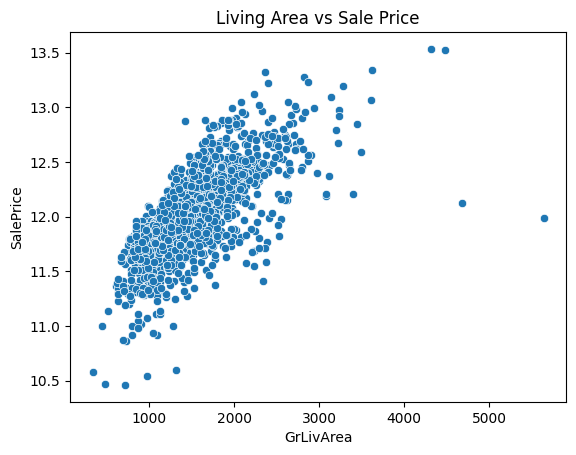

In [173]:
sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"])
plt.title("Living Area vs Sale Price")
plt.show()

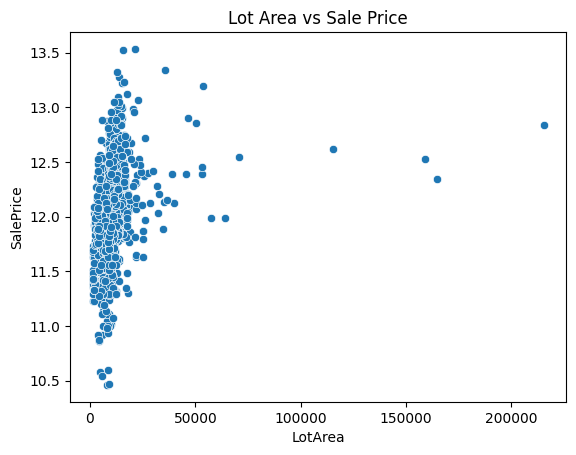

In [174]:
sns.scatterplot(x=df["LotArea"], y=df["SalePrice"])
plt.title("Lot Area vs Sale Price")
plt.show()

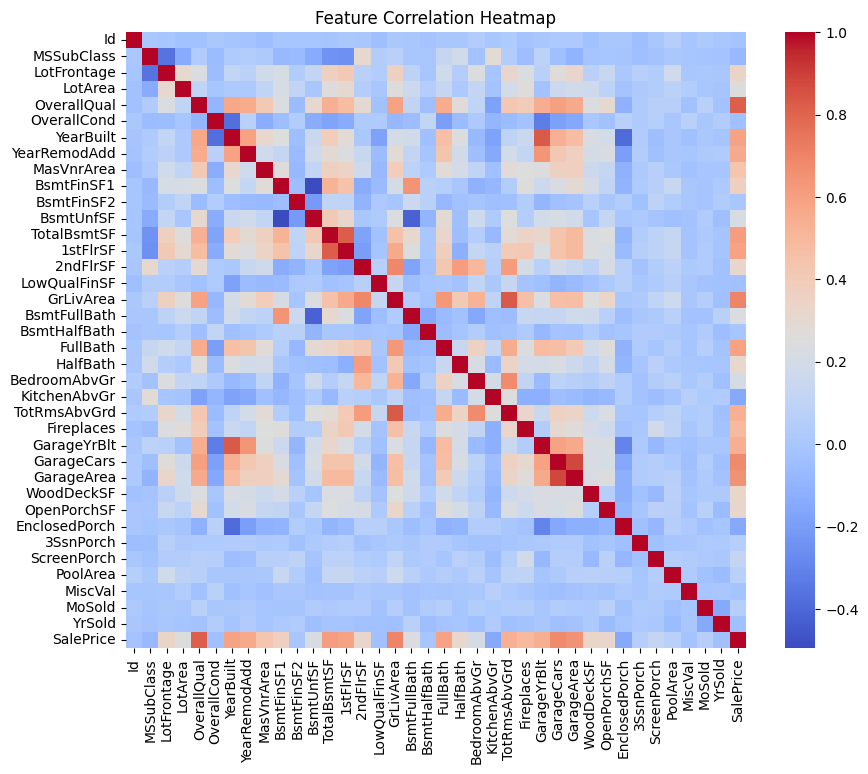

In [175]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")

plt.show()

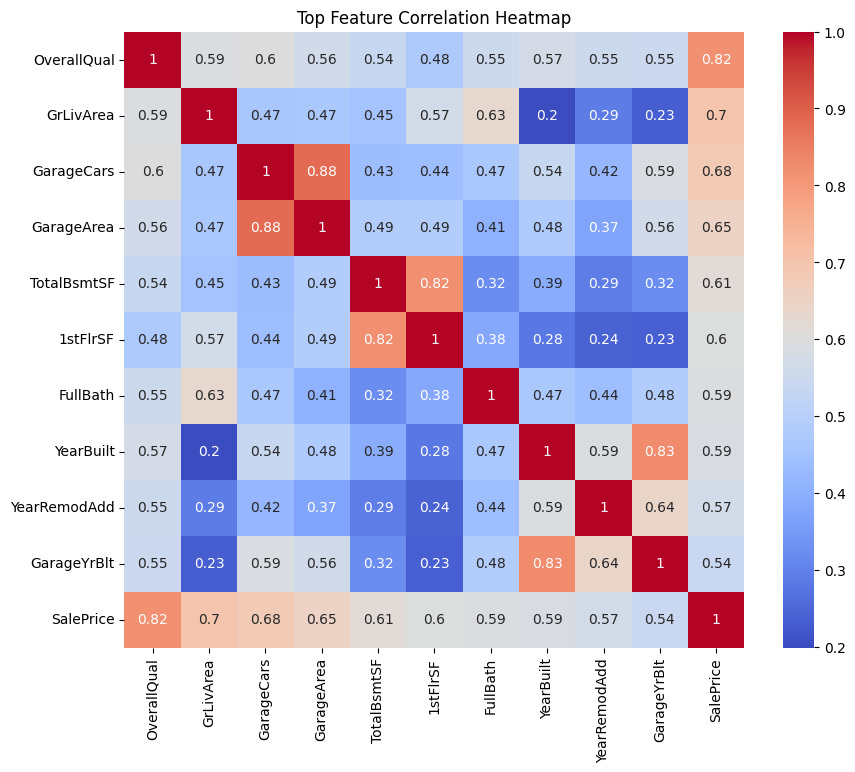

In [176]:
corr = df.corr(numeric_only=True)["SalePrice"].abs().sort_values(ascending=False)

top_features = corr.drop("SalePrice").head(10).index

plt.figure(figsize=(10,8))
sns.heatmap(df[top_features.tolist() + ["SalePrice"]].corr(), 
            annot=True, cmap="coolwarm")

plt.title("Top Feature Correlation Heatmap")
plt.show()

In [177]:
# print(df[["GrLivArea", "SalePrice"]].corr())

corr = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

top5 = corr[1:6]   # skip SalePrice itself (index 0)
print(top5)

OverallQual    0.817184
GrLivArea      0.700927
GarageCars     0.680625
GarageArea     0.650888
TotalBsmtSF    0.612134
Name: SalePrice, dtype: float64


In [178]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

X = df[["GrLivArea", "GarageCars", "OverallQual","TotalBsmtSF","GarageArea"]]
y = df["SalePrice"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [179]:
model = LinearRegression()#Price = w1*feature1 + w2*feature2 + ... + b(y=mx+b)
#price = 100*size + 5000*rooms......so on 
# Takes input (X_train)
# Makes prediction
# Compares with actual (y_train)
# Adjusts weights
# Repeats many times
# 👉 This is optimization

model.fit(X_train,y_train)#Learn pattern from known data
y_pred_log = model.predict(X_test)

# 5. Convert BOTH to original scale ✅
y_pred = np.exp(y_pred_log)
y_test_actual = np.exp(y_test)


print(y_pred)
print(y_pred.shape)
# print(y_test.shape)
# print(y_test)


[ 168922.97741203  346325.63434736  189077.51149914  190472.48682378
  155218.88995013  143544.10292511  147713.93758836  259041.12895238
  134560.17100321  280863.51548421  235305.06778178  221770.29774793
  122784.75509086  129198.48766018  203807.63260782  168927.79640898
  199831.61922184  121039.11269488  233118.06295059  100770.43215958
  270572.53436505  183133.96995082  172891.29504224  120594.9676875
  200523.32965173 1913527.30752872  177219.73807701  109461.66649093
  195633.23318775   89211.62596883  128685.67078805  134420.02503813
  110363.01976991  266346.74676071  204990.62105244  234543.89771163
  114522.80949965  166643.29692084  187002.29641248  166325.94340981
  193348.64000027   96864.56503408   86275.18484511  102079.80837536
  113222.99110104  126552.93140612  205685.71469943  143943.23453023
   97660.6196931   135144.34574005  194158.61144817  190804.30875623
  143937.17640945  151101.736266    121631.91347483  177635.05868744
  185323.02915639  145022.98213667 

In [180]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test_actual, y_pred)

error_percent = mae / np.mean(y_test_actual) * 100

print("MAE:", mae)
print("Error %:", error_percent)

MAE: 27955.435808311107
Error %: 15.042501640344415


In [181]:
# #error jugde
# var = mae / np.mean(y_test_actual) * 100
# print(var)#On average, your model is off by ~17.28732546012541%

In [185]:
model = DecisionTreeRegressor()
model.fit(X_train,y_train)


y_pred_log = model.predict(X_test)
y_pred = np.exp(y_pred_log)


y_test_actual = np.exp(y_test)

mae = mean_absolute_error(y_test_actual, y_pred)
print(mae)

30539.86498859815


In [186]:
# error_percent = mae / np.mean(y_test_actual) * 100

error_percent = mae / np.mean(y_test_actual) * 100

print("MAE:", mae)
print("Error %:", error_percent)

MAE: 30539.86498859815
Error %: 16.433153549704528
